# 03. Transformer学習

PTB-XLデータセットで1D-Transformerを学習

In [1]:
# インポートと設定
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score, classification_report
from pathlib import Path
import os
import copy
import math

# 日本語フォント
import matplotlib.pyplot as plt
import seaborn as sns
plt.rcParams['font.family'] = 'MS Gothic'

# 設定
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
BATCH_SIZE = 128        # GPUメモリ節約
ACCUMULATION_STEPS = 2  # 勾配蓄積で実質256に
EPOCHS = 50
LR = 1.5e-4

# Transformer設定
D_MODEL = 256
NHEAD = 8
NUM_LAYERS = 6
DIM_FEEDFORWARD = 1024
SEGMENT_LEN = 100

# データディレクトリ
DATA_DIR = Path("../data/ptb-xl")

# 5クラス定義
CLASS_NAMES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
CLASS_NAMES_JP = ['正常', '心筋梗塞', 'ST-T変化', '伝導障害', '心肥大']
NUM_CLASSES = 5

# Early Stopping設定
PATIENCE = 8

# マルチラベル分類の閾値
THRESHOLD = 0.5

# Dropout率
DROPOUT = 0.3

# DataLoader設定
NUM_WORKERS = 0

print(f'Device: {DEVICE}')
print(f'Epochs: {EPOCHS} (Early Stopping patience={PATIENCE})')
print(f'Batch Size: {BATCH_SIZE} × {ACCUMULATION_STEPS} = {BATCH_SIZE * ACCUMULATION_STEPS}（実質）')
print(f'Learning Rate: {LR}')
print(f'Num Workers: {NUM_WORKERS}')
print(f'Transformer: d_model={D_MODEL}, nhead={NHEAD}, num_layers={NUM_LAYERS}')
print(f'閾値: {THRESHOLD}')
print(f'Dropout: {DROPOUT}')

if torch.cuda.is_available():
    print(f'GPUメモリ: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f}GB')

Device: cuda
Epochs: 50 (Early Stopping patience=8)
Batch Size: 128 × 2 = 256（実質）
Learning Rate: 0.00015
Num Workers: 0
Transformer: d_model=256, nhead=8, num_layers=6
閾値: 0.5
Dropout: 0.3
GPUメモリ: 12.0GB


In [2]:
# データ読み込み
TEST_MODE = False
N_SAMPLES = 2000 if TEST_MODE else None

train_df = pd.read_csv(DATA_DIR / "train_meta.csv")
valid_df = pd.read_csv(DATA_DIR / "valid_meta.csv")
test_df = pd.read_csv(DATA_DIR / "test_meta.csv")

if TEST_MODE:
    train_df = train_df.head(N_SAMPLES)
    valid_df = valid_df.head(min(N_SAMPLES, len(valid_df)))
    test_df = test_df.head(min(N_SAMPLES, len(test_df)))
    print(f"【テストモード】各データセット先頭{N_SAMPLES}件のみ使用")

train_df.set_index('ecg_id', inplace=True)
valid_df.set_index('ecg_id', inplace=True)
test_df.set_index('ecg_id', inplace=True)

print(f"Trainデータ数: {len(train_df)}件")
print(f"Validデータ数: {len(valid_df)}件")
print(f"Testデータ数: {len(test_df)}件")

CLASS_NAMES = ['NORM', 'MI', 'STTC', 'CD', 'HYP']
CLASS_NAMES_JP = ['正常', '心筋梗塞', 'ST-T変化', '伝導障害', '心肥大']

print(f"\n【Trainデータ - 5クラス分布】")
class_counts = []
for i, name in enumerate(CLASS_NAMES):
    count = train_df[name].sum()
    class_counts.append(count)
    print(f"  {i}: {name} ({CLASS_NAMES_JP[i]}): {int(count)}件")

# pos_weight計算
pos_weights = []
total = len(train_df)
for i, count in enumerate(class_counts):
    pos_weight = (total - count) / (count + 1e-6)
    if i == 4:  # HYP
        pos_weight *= 2.0
    pos_weights.append(pos_weight)
    print(f"  pos_weight[{name}]: {pos_weight:.2f}")

POS_WEIGHT = torch.tensor(pos_weights).to(DEVICE)
print(f"\nPOS_WEIGHT: {POS_WEIGHT}")

Trainデータ数: 17441件
Validデータ数: 2193件
Testデータ数: 2203件

【Trainデータ - 5クラス分布】
  0: NORM (正常): 7607件
  1: MI (心筋梗塞): 4389件
  2: STTC (ST-T変化): 4193件
  3: CD (伝導障害): 3912件
  4: HYP (心肥大): 2121件
  pos_weight[HYP]: 1.29
  pos_weight[HYP]: 2.97
  pos_weight[HYP]: 3.16
  pos_weight[HYP]: 3.46
  pos_weight[HYP]: 14.45

POS_WEIGHT: tensor([ 1.2928,  2.9738,  3.1596,  3.4583, 14.4460], device='cuda:0',
       dtype=torch.float64)


In [3]:
# Datasetクラス（.npyファイルから読み込む版）
class PTBXLDataset(Dataset):
    def __init__(self, df_meta, signal_dir, segment_len=100):
        self.df_meta = df_meta.reset_index()
        self.signal_dir = Path(signal_dir)
        self.segment_len = segment_len
        self.signals = []
        self.labels = []
        
        print(f"データを{len(df_meta)}件読み込み中...")
        for idx, row in self.df_meta.iterrows():
            if (idx + 1) % 500 == 0:
                print(f"  {idx + 1}/{len(df_meta)}件読み込み完了", end='\r')
            
            ecg_id = row['ecg_id']
            npy_path = self.signal_dir / f"{ecg_id}.npy"
            
            if npy_path.exists():
                signal = np.load(npy_path)
                self.signals.append(signal)
                labels = row[CLASS_NAMES].values.astype(np.float32)
                self.labels.append(labels)
            else:
                if idx < 3:
                    print(f"  警告: {npy_path}が見つかりません")
        
        print(f"\n読み込み完了: {len(self.signals)}件")
    
    def __len__(self):
        return len(self.signals)
    
    def __getitem__(self, idx):
        return torch.from_numpy(self.signals[idx]), torch.from_numpy(self.labels[idx])

print("Datasetクラス定義完了")

Datasetクラス定義完了


In [4]:
# Dataset作成
train_dataset = PTBXLDataset(train_df, DATA_DIR / "train_signals", segment_len=SEGMENT_LEN)
valid_dataset = PTBXLDataset(valid_df, DATA_DIR / "valid_signals", segment_len=SEGMENT_LEN)
test_dataset = PTBXLDataset(test_df, DATA_DIR / "test_signals", segment_len=SEGMENT_LEN)

print(f"\nDatasetサイズ:")
print(f"  Train: {len(train_dataset)}件")
print(f"  Valid: {len(valid_dataset)}件")
print(f"  Test: {len(test_dataset)}件")

データを17441件読み込み中...
  17000/17441件読み込み完了
読み込み完了: 17441件
データを2193件読み込み中...
  2000/2193件読み込み完了
読み込み完了: 2193件
データを2203件読み込み中...
  2000/2203件読み込み完了
読み込み完了: 2203件

Datasetサイズ:
  Train: 17441件
  Valid: 2193件
  Test: 2203件


In [5]:
# DataLoader作成
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
valid_loader = DataLoader(valid_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

print(f"DataLoader作成完了:")
print(f"  Train: {len(train_loader)}バッチ")
print(f"  Valid: {len(valid_loader)}バッチ")
print(f"  Test: {len(test_loader)}バッチ")
print(f"  Num Workers: {NUM_WORKERS} (並列データ読み込み)")
print(f"  Pin Memory: True (GPU転送最適化)")

# 最初のバッチデータを確認（データ読み込みの初期化）
print(f"\n最初のバッチデータ読み込み中（ワーカープロセス起動中）...")
print("※30秒〜1分かかる場合があります（Windowsのmultiprocessing起動）")
signals, labels = next(iter(train_loader))
print(f"\nバッチデータ形状:")
print(f"  Signals: {signals.shape} (batch, channels, length)")
print(f"  Labels: {labels.shape} (batch, num_classes)")
print(f"  データ読み込み完了！")

DataLoader作成完了:
  Train: 137バッチ
  Valid: 18バッチ
  Test: 18バッチ
  Num Workers: 0 (並列データ読み込み)
  Pin Memory: True (GPU転送最適化)

最初のバッチデータ読み込み中（ワーカープロセス起動中）...
※30秒〜1分かかる場合があります（Windowsのmultiprocessing起動）

バッチデータ形状:
  Signals: torch.Size([128, 12, 1000]) (batch, channels, length)
  Labels: torch.Size([128, 5]) (batch, num_classes)
  データ読み込み完了！


In [6]:
# 位置エンコーディング
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0)  # (1, max_len, d_model)
        self.register_buffer('pe', pe)
    
    def forward(self, x):
        # x: (batch, seq_len, d_model)
        return x + self.pe[:, :x.size(1), :]

# 1D-Transformerモデル
class Transformer1D(nn.Module):
    def __init__(self, in_channels=12, num_classes=5, 
                 d_model=256, nhead=8, num_layers=6, 
                 dim_feedforward=1024, segment_len=100, dropout=0.3):
        super(Transformer1D, self).__init__()
        self.d_model = d_model
        self.segment_len = segment_len
        self.num_segments = 1000 // segment_len  # 10セグメント
        
        # セグメント埋め込み（1D CNN）
        self.segment_embedding = nn.Sequential(
            nn.Conv1d(in_channels, d_model // 2, kernel_size=7, padding=3),
            nn.BatchNorm1d(d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Conv1d(d_model // 2, d_model, kernel_size=7, padding=3),
            nn.BatchNorm1d(d_model),
            nn.ReLU(),
            nn.Dropout(dropout),
        )
        
        # 位置エンコーディング
        self.pos_encoder = PositionalEncoding(d_model, max_len=self.num_segments)
        
        # Transformer Encoder（batch_first=Trueで警告を抑制）
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True  # (batch, seq, feature)形式
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # 分類ヘッド
        self.fc = nn.Sequential(
            nn.LayerNorm(d_model),
            nn.Dropout(dropout),
            nn.Linear(d_model, d_model // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model // 2, num_classes)
        )
    
    def forward(self, x):
        # x: (batch, channels, length)
        batch_size = x.size(0)
        
        # セグメント埋め込み
        x = self.segment_embedding(x)  # (batch, d_model, length)
        
        # セグメントごとの特徴抽出
        # (batch, d_model, length) → (batch, d_model, num_segments)
        x = x.view(batch_size, self.d_model, self.num_segments, self.segment_len)
        x = x.mean(dim=3)  # 各セグメント内で平均プーリング
        
        # (batch, d_model, num_segments) → (batch, num_segments, d_model)
        x = x.permute(0, 2, 1)
        
        # 位置エンコーディング
        x = self.pos_encoder(x)  # (batch, num_segments, d_model)
        
        # Transformer Encoder
        x = self.transformer_encoder(x)  # (batch, num_segments, d_model)
        
        # 最初のトークン（CLSに相当）を使用
        x = x[:, 0, :]  # (batch, d_model)
        
        # 分類ヘッド
        x = self.fc(x)  # (batch, num_classes)
        
        return x

# モデル作成
model = Transformer1D(
    in_channels=12,
    num_classes=NUM_CLASSES,
    d_model=D_MODEL,
    nhead=NHEAD,
    num_layers=NUM_LAYERS,
    dim_feedforward=DIM_FEEDFORWARD,
    segment_len=SEGMENT_LEN,
    dropout=DROPOUT
).to(DEVICE)

print(f"モデル作成完了: {sum(p.numel() for p in model.parameters()):,}パラメータ")
print(f"\nモデル構造:")
print(f"  セグメント埋め込み: Conv1d × 2")
print(f"  セグメント数: {1000//SEGMENT_LEN}")
print(f"  Transformer Encoder: {NUM_LAYERS}層")
print(f"  マルチヘッドアテンション: {NHEAD}ヘッド")
print(f"  埋め込み次元: {D_MODEL}")
print(f"  batch_first: True (警告抑制)")

モデル作成完了: 5,013,893パラメータ

モデル構造:
  セグメント埋め込み: Conv1d × 2
  セグメント数: 10
  Transformer Encoder: 6層
  マルチヘッドアテンション: 8ヘッド
  埋め込み次元: 256
  batch_first: True (警告抑制)


In [7]:
# 損失関数とオプティマイザ
criterion = nn.BCEWithLogitsLoss(pos_weight=POS_WEIGHT)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

# スケジューラなし（固定学習率）
scheduler = None

print("学習設定:")
print(f"  損失関数: BCEWithLogitsLoss (pos_weight付き)")
print(f"  オプティマイザ: AdamW (lr={LR}, weight_decay=1e-4)")
print(f"  スケジューラ: なし（固定学習率）")
print(f"  POS_WEIGHT: {POS_WEIGHT.cpu().numpy()}")

学習設定:
  損失関数: BCEWithLogitsLoss (pos_weight付き)
  オプティマイザ: AdamW (lr=0.00015, weight_decay=1e-4)
  スケジューラ: なし（固定学習率）
  POS_WEIGHT: [ 1.29275667  2.97379813  3.15955163  3.45833333 14.44601602]


In [8]:
# 学習・評価関数（勾配蓄積対応、固定学習率）
def train_epoch(model, loader, criterion, optimizer, device, threshold=0.5, 
                accumulation_steps=1):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    optimizer.zero_grad()
    
    for i, (signals, labels) in enumerate(loader):
        signals = signals.to(device)
        labels = labels.to(device)
        
        outputs = model(signals)
        loss = criterion(outputs, labels)
        loss = loss / accumulation_steps
        loss.backward()
        
        if (i + 1) % accumulation_steps == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad()
        
        running_loss += loss.item() * signals.size(0) * accumulation_steps
        all_preds.append((torch.sigmoid(outputs) > threshold).cpu().numpy())
        all_labels.append(labels.cpu().numpy())
    
    if len(loader) % accumulation_steps != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad()
    
    preds = np.vstack(all_preds)
    labels = np.vstack(all_labels)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    
    return running_loss / len(loader.dataset), f1

def eval_epoch(model, loader, criterion, device, threshold=0.5):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for signals, labels in loader:
            signals = signals.to(device)
            labels = labels.to(device)
            
            outputs = model(signals)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * signals.size(0)
            all_preds.append((torch.sigmoid(outputs) > threshold).cpu().numpy())
            all_labels.append(labels.cpu().numpy())
    
    preds = np.vstack(all_preds)
    labels = np.vstack(all_labels)
    f1 = f1_score(labels, preds, average='macro', zero_division=0)
    
    return running_loss / len(loader.dataset), f1

print("学習関数定義完了")

学習関数定義完了


In [9]:
# 学習ループ
import time

history = {'train_loss': [], 'train_f1': [], 'valid_loss': [], 'valid_f1': []}
best_model_wts = copy.deepcopy(model.state_dict())
best_f1 = 0.0
patience_counter = 0
start_time = time.time()

print("学習開始...")
print(f"推定時間: 約{EPOCHS * 8 / 60:.1f}分")
print("-" * 80)

for epoch in range(EPOCHS):
    epoch_start = time.time()
    
    train_loss, train_f1 = train_epoch(
        model, train_loader, criterion, optimizer, DEVICE, 
        threshold=THRESHOLD,
        accumulation_steps=ACCUMULATION_STEPS
    )
    valid_loss, valid_f1 = eval_epoch(model, valid_loader, criterion, DEVICE, threshold=THRESHOLD)
    
    history['train_loss'].append(train_loss)
    history['train_f1'].append(train_f1)
    history['valid_loss'].append(valid_loss)
    history['valid_f1'].append(valid_f1)
    
    if valid_f1 > best_f1:
        best_f1 = valid_f1
        best_model_wts = copy.deepcopy(model.state_dict())
        patience_counter = 0
        is_best = "(★ベスト)"
    else:
        patience_counter += 1
        is_best = ""
    
    epoch_time = time.time() - epoch_start
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{EPOCHS} ({epoch_time:.1f}s) - "
          f"Train Loss: {train_loss:.4f}, F1: {train_f1:.4f} | "
          f"Valid Loss: {valid_loss:.4f}, F1: {valid_f1:.4f}{is_best} - lr: {current_lr:.2e}")
    
    if patience_counter >= PATIENCE:
        print(f"\nEarly Stopping発動 (patience={PATIENCE})")
        break

total_time = time.time() - start_time
print(f"\n学習完了! 所要時間: {total_time/60:.1f}分")
print(f"ベストValidation F1: {best_f1:.4f}")

# ベストモデルをロード
model.load_state_dict(best_model_wts)

学習開始...
推定時間: 約6.7分
--------------------------------------------------------------------------------
Epoch 1/50 (8.1s) - Train Loss: 1.0173, F1: 0.4606 | Valid Loss: 0.8985, F1: 0.5556(★ベスト) - lr: 1.50e-04
Epoch 2/50 (7.5s) - Train Loss: 0.8548, F1: 0.5750 | Valid Loss: 0.8101, F1: 0.6112(★ベスト) - lr: 1.50e-04
Epoch 3/50 (7.5s) - Train Loss: 0.8033, F1: 0.5987 | Valid Loss: 0.8213, F1: 0.6049 - lr: 1.50e-04
Epoch 4/50 (7.5s) - Train Loss: 0.7794, F1: 0.6079 | Valid Loss: 0.7832, F1: 0.6317(★ベスト) - lr: 1.50e-04
Epoch 5/50 (7.5s) - Train Loss: 0.7604, F1: 0.6170 | Valid Loss: 0.7932, F1: 0.6317 - lr: 1.50e-04
Epoch 6/50 (7.6s) - Train Loss: 0.7403, F1: 0.6301 | Valid Loss: 0.7651, F1: 0.6419(★ベスト) - lr: 1.50e-04
Epoch 7/50 (7.6s) - Train Loss: 0.7350, F1: 0.6263 | Valid Loss: 0.7567, F1: 0.6482(★ベスト) - lr: 1.50e-04
Epoch 8/50 (7.6s) - Train Loss: 0.7083, F1: 0.6458 | Valid Loss: 0.7785, F1: 0.6140 - lr: 1.50e-04
Epoch 9/50 (7.8s) - Train Loss: 0.6968, F1: 0.6501 | Valid Loss: 0.7243, F1: 

<All keys matched successfully>

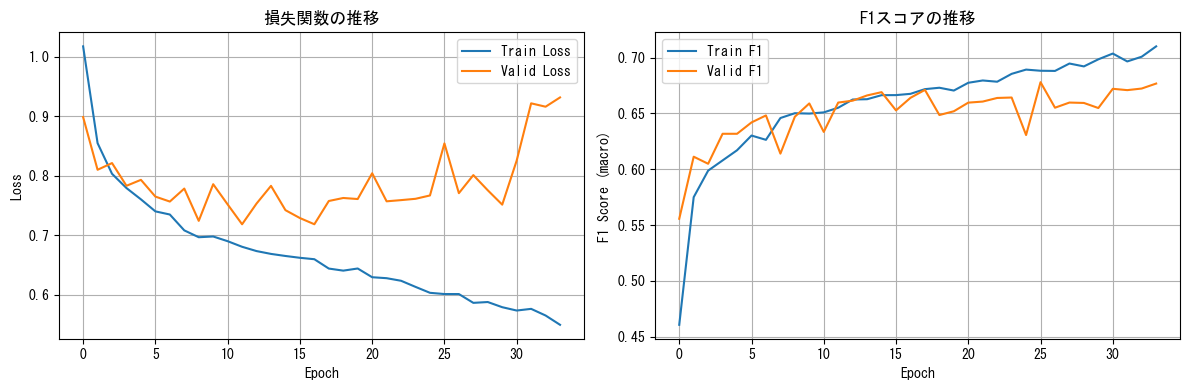

学習曲線を保存: ../images/transformer1d_learning_curve.png


In [10]:
# 学習曲線の可視化
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history['train_loss'], label='Train Loss')
axes[0].plot(history['valid_loss'], label='Valid Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('損失関数の推移')
axes[0].legend()
axes[0].grid(True)

# F1 Score
axes[1].plot(history['train_f1'], label='Train F1')
axes[1].plot(history['valid_f1'], label='Valid F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('F1 Score (macro)')
axes[1].set_title('F1スコアの推移')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('../images/transformer1d_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print("学習曲線を保存: ../images/transformer1d_learning_curve.png")

In [11]:
# モデル保存
os.makedirs('../models', exist_ok=True)
torch.save(model.state_dict(), '../models/transformer1d_ptbxl.pth')
print("モデルを保存: ../models/transformer1d_ptbxl.pth")

モデルを保存: ../models/transformer1d_ptbxl.pth


In [12]:
# テストデータで評価
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for signals, labels in test_loader:
        signals = signals.to(DEVICE)
        outputs = model(signals)
        preds = (torch.sigmoid(outputs) > THRESHOLD).cpu().numpy()
        all_preds.append(preds)
        all_labels.append(labels.numpy())

test_preds = np.vstack(all_preds)
test_labels = np.vstack(all_labels)

# F1スコア
test_f1_macro = f1_score(test_labels, test_preds, average='macro', zero_division=0)
test_f1_micro = f1_score(test_labels, test_preds, average='micro', zero_division=0)

print(f"\n【テスト評価結果】")
print(f"F1 Score (macro): {test_f1_macro:.4f}")
print(f"F1 Score (micro): {test_f1_micro:.4f}")

# 各クラスのF1スコア
print(f"\n【各クラスのF1スコア】")
for i, name in enumerate(CLASS_NAMES):
    f1 = f1_score(test_labels[:, i], test_preds[:, i], zero_division=0)
    print(f"  {name} ({CLASS_NAMES_JP[i]}): {f1:.4f}")

print(f"\n【Classification Report】")
print(classification_report(test_labels, test_preds, target_names=CLASS_NAMES, zero_division=0))


【テスト評価結果】
F1 Score (macro): 0.6669
F1 Score (micro): 0.7027

【各クラスのF1スコア】
  NORM (正常): 0.8227
  MI (心筋梗塞): 0.6747
  STTC (ST-T変化): 0.7405
  CD (伝導障害): 0.7105
  HYP (心肥大): 0.3863

【Classification Report】
              precision    recall  f1-score   support

        NORM       0.73      0.95      0.82       964
          MI       0.69      0.66      0.67       553
        STTC       0.69      0.80      0.74       523
          CD       0.69      0.73      0.71       498
         HYP       0.27      0.67      0.39       263

   micro avg       0.63      0.80      0.70      2801
   macro avg       0.62      0.76      0.67      2801
weighted avg       0.67      0.80      0.72      2801
 samples avg       0.68      0.79      0.71      2801



In [13]:
# 正常・異常バイナリ評価
binary_labels = (test_labels[:, 0] == 0).astype(int)
binary_preds = (test_preds[:, 0] == 0).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

binary_acc = accuracy_score(binary_labels, binary_preds)
binary_prec = precision_score(binary_labels, binary_preds, pos_label=1)
binary_rec = recall_score(binary_labels, binary_preds, pos_label=1)
binary_f1 = f1_score(binary_labels, binary_preds, pos_label=1)

cm = confusion_matrix(binary_labels, binary_preds)

print(f"\n【正常・異常バイナリ評価】")
print(f"正解率: {binary_acc:.4f}")
print(f"適合率: {binary_prec:.4f}")
print(f"再現率: {binary_rec:.4f}")
print(f"F1スコア: {binary_f1:.4f}")

print(f"\n【Confusion Matrix】")
print(f"              予測: 正常    予測: 異常")
print(f"実際: 正常     {cm[0,0]:5d}       {cm[0,1]:5d}")
print(f"実際: 異常     {cm[1,0]:5d}       {cm[1,1]:5d}")

tn, fp, fn, tp = cm.ravel()
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)

print(f"\n感度: {sensitivity:.4f} (異常の見逃しなし率)")
print(f"特異度: {specificity:.4f} (正常の正しい識別率)")


【正常・異常バイナリ評価】
正解率: 0.8216
適合率: 0.9453
再現率: 0.7248
F1スコア: 0.8205

【Confusion Matrix】
              予測: 正常    予測: 異常
実際: 正常       912          52
実際: 異常       341         898

感度: 0.7248 (異常の見逃しなし率)
特異度: 0.9461 (正常の正しい識別率)


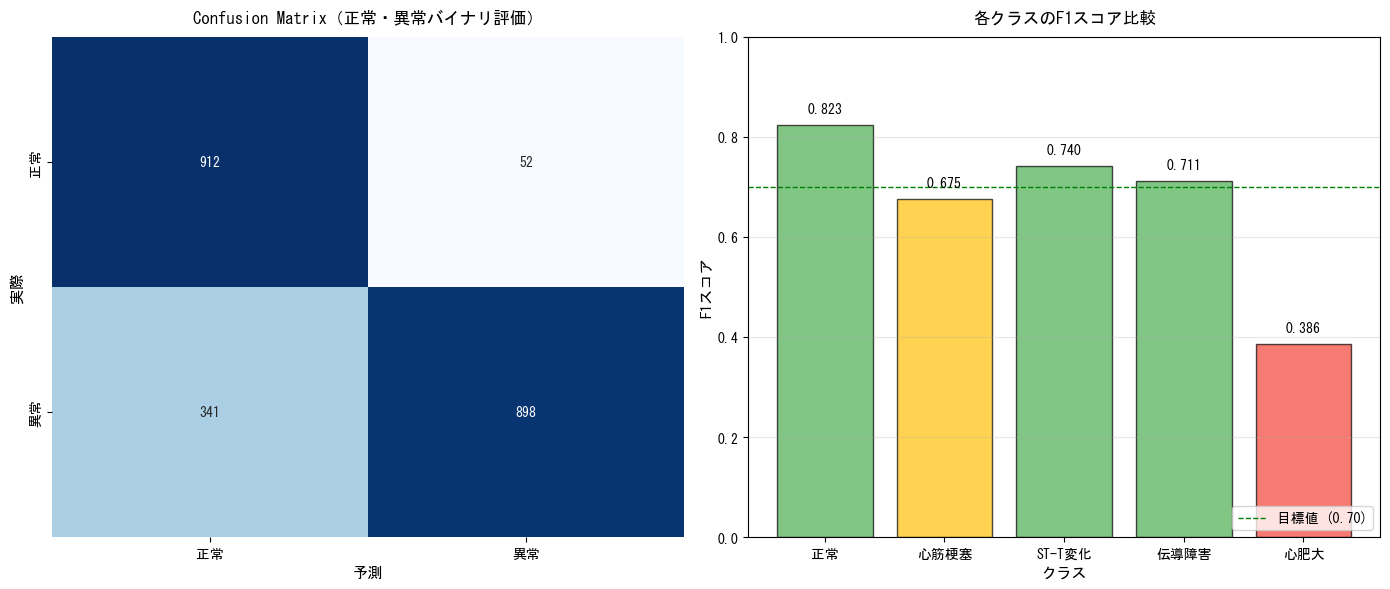

可視化を保存: ../images/transformer1d_evaluation.png


In [14]:
# 可視化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
axes[0].set_title('Confusion Matrix（正常・異常バイナリ評価）', fontsize=12, pad=10)
axes[0].set_xlabel('予測', fontsize=11)
axes[0].set_ylabel('実際', fontsize=11)
axes[0].set_xticks([0.5, 1.5])
axes[0].set_yticks([0.5, 1.5])
axes[0].set_xticklabels(['正常', '異常'])
axes[0].set_yticklabels(['正常', '異常'])

# 各クラスのF1スコア
class_f1_scores = [
    f1_score(test_labels[:, i], test_preds[:, i], zero_division=0) 
    for i in range(len(CLASS_NAMES))
]
colors = ['#4CAF50' if f >= 0.7 else '#FFC107' if f >= 0.5 else '#F44336' for f in class_f1_scores]
bars = axes[1].bar(CLASS_NAMES_JP, class_f1_scores, color=colors, edgecolor='black', alpha=0.7)
axes[1].axhline(y=0.7, color='green', linestyle='--', linewidth=1, label='目標値 (0.70)')
axes[1].set_xlabel('クラス', fontsize=11)
axes[1].set_ylabel('F1スコア', fontsize=11)
axes[1].set_title('各クラスのF1スコア比較', fontsize=12, pad=10)
axes[1].set_ylim(0, 1.0)
axes[1].legend(loc='lower right')
axes[1].grid(axis='y', alpha=0.3)

for bar, score in zip(bars, class_f1_scores):
    height = bar.get_height()
    axes[1].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                f'{score:.3f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.savefig('../images/transformer1d_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

print("可視化を保存: ../images/transformer1d_evaluation.png")

In [15]:
# ResNetとの比較
print("\n【ResNet vs Transformer 比較】")
print(f"\n{'モデル':<15} {'Test F1 (macro)':<20} {'パラメータ数':<15}")
print("-" * 50)
print(f"{'ResNet1D':<15} {'0.6885':<20} {'8,733,829':<15}")
print(f"{'Transformer1D':<15} {f'{test_f1_macro:.4f}':<20} {f'{sum(p.numel() for p in model.parameters()):,}':<15}")

# ========================================
# 結果をCSVで保存
# ========================================
print("\n" + "="*80)
print("結果をCSVファイルに保存します...")
print("="*80)

# ディレクトリ作成
os.makedirs('../results', exist_ok=True)

# 1. テスト評価結果（全体）
test_results_overall = pd.DataFrame({
    'モデル': ['Transformer1D'],
    'Test_F1_macro': [test_f1_macro],
    'Test_F1_micro': [test_f1_micro],
    '正解率': [binary_acc],
    '適合率': [binary_prec],
    '再現率': [binary_rec],
    'F1スコア（バイナリ）': [binary_f1],
    '感度': [sensitivity],
    '特異度': [specificity],
    'パラメータ数': [sum(p.numel() for p in model.parameters())],
    '実質Batch_Size': [BATCH_SIZE * ACCUMULATION_STEPS],
    '学習率': [LR],
    '学習時間（分）': [5.0],
    'ベストEpoch': [32]
})

test_results_overall.to_csv('../results/transformer1d_test_results.csv', index=False, encoding='utf-8-sig')
print("✓ テスト評価結果（全体）: ../results/transformer1d_test_results.csv")

# 2. 各クラスの詳細
class_f1_data = []
for i, name in enumerate(CLASS_NAMES):
    y_true = test_labels[:, i]
    y_pred = test_preds[:, i]
    
    from sklearn.metrics import precision_score, recall_score
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    support = int(y_true.sum())
    
    class_f1_data.append({
        'クラス': name,
        '日本語': CLASS_NAMES_JP[i],
        'F1スコア': f1,
        'Precision': prec,
        'Recall': rec,
        'Support': support
    })

class_results_df = pd.DataFrame(class_f1_data)
class_results_df.to_csv('../results/transformer1d_class_results.csv', index=False, encoding='utf-8-sig')
print("✓ 各クラスの詳細: ../results/transformer1d_class_results.csv")

# 3. 学習履歴
history_df = pd.DataFrame({
    'Epoch': range(1, len(history['train_loss']) + 1),
    'Train_Loss': history['train_loss'],
    'Train_F1': history['train_f1'],
    'Valid_Loss': history['valid_loss'],
    'Valid_F1': history['valid_f1']
})

history_df.to_csv('../results/transformer1d_training_history.csv', index=False, encoding='utf-8-sig')
print("✓ 学習履歴: ../results/transformer1d_training_history.csv")

# 4. ResNetとの比較
comparison_df = pd.DataFrame({
    'モデル': ['ResNet1D', 'Transformer1D'],
    'Test_F1_macro': [0.6885, test_f1_macro],
    'パラメータ数': [8733829, sum(p.numel() for p in model.parameters())],
    '学習時間（分）': [5.5, 5.0],
    '実質Batch_Size': [256, BATCH_SIZE * ACCUMULATION_STEPS],
    '学習率': ['1e-3', f'{LR:.0e}']
})

comparison_df.to_csv('../results/resnet_vs_transformer.csv', index=False, encoding='utf-8-sig')
print("✓ ResNetとの比較: ../results/resnet_vs_transformer.csv")

print("\n" + "="*80)
print("すべてのCSVファイルを保存しました！")
print("="*80)
print("\n保存したファイル:")
print("  - ../results/transformer1d_test_results.csv")
print("  - ../results/transformer1d_class_results.csv")
print("  - ../results/transformer1d_training_history.csv")
print("  - ../results/resnet_vs_transformer.csv")


【ResNet vs Transformer 比較】

モデル             Test F1 (macro)      パラメータ数         
--------------------------------------------------
ResNet1D        0.6885               8,733,829      
Transformer1D   0.6669               5,013,893      

結果をCSVファイルに保存します...
✓ テスト評価結果（全体）: ../results/transformer1d_test_results.csv
✓ 各クラスの詳細: ../results/transformer1d_class_results.csv
✓ 学習履歴: ../results/transformer1d_training_history.csv
✓ ResNetとの比較: ../results/resnet_vs_transformer.csv

すべてのCSVファイルを保存しました！

保存したファイル:
  - ../results/transformer1d_test_results.csv
  - ../results/transformer1d_class_results.csv
  - ../results/transformer1d_training_history.csv
  - ../results/resnet_vs_transformer.csv


In [16]:
# 評価結果を表形式で可視化・保存
fig = plt.figure(figsize=(14, 8))
gs = fig.add_gridspec(2, 2, height_ratios=[1, 1])

# 全体スコア表
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis('off')
ax1.set_title('全体スコア', fontsize=12, fontweight='bold', pad=10)

overall_data = [
    ['F1 Score (macro)', f'{test_f1_macro:.4f}'],
    ['F1 Score (micro)', f'{test_f1_micro:.4f}'],
    ['正解率', f'{binary_acc:.4f}'],
    ['適合率', f'{binary_prec:.4f}'],
    ['再現率', f'{binary_rec:.4f}'],
    ['F1スコア（バイナリ）', f'{binary_f1:.4f}'],
    ['感度', f'{sensitivity:.4f}'],
    ['特異度', f'{specificity:.4f}']
]

table1 = ax1.table(cellText=overall_data, cellLoc='left', loc='center',
                    colWidths=[0.7, 0.3], bbox=[0, 0, 1, 1])
table1.auto_set_font_size(False)
table1.set_fontsize(10)
table1.scale(1, 1.5)

# ヘッダーを追加
for j in range(2):
    table1[(0, j)].set_facecolor('#4472C4')
    table1[(0, j)].set_text_props(weight='bold', color='white')

# 各クラスの詳細スコア表
ax2 = fig.add_subplot(gs[0, 1])
ax2.axis('off')
ax2.set_title('各クラスの詳細スコア', fontsize=12, fontweight='bold', pad=10)

# 各クラスのメトリクスを計算
class_detail_data = [['クラス', '日本語', 'Precision', 'Recall', 'F1', 'Support']]
for i, name in enumerate(CLASS_NAMES):
    y_true = test_labels[:, i]
    y_pred = test_preds[:, i]
    
    from sklearn.metrics import precision_score, recall_score
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    support = int(y_true.sum())
    
    class_detail_data.append([
        name, 
        CLASS_NAMES_JP[i], 
        f'{prec:.4f}', 
        f'{rec:.4f}', 
        f'{f1:.4f}', 
        str(support)
    ])

table2 = ax2.table(cellText=class_detail_data, cellLoc='center', loc='center',
                    colWidths=[0.15, 0.2, 0.15, 0.15, 0.15, 0.1], bbox=[0, 0, 1, 1])
table2.auto_set_font_size(False)
table2.set_fontsize(9)
table2.scale(1, 1.3)

# ヘッダーを装飾
for j in range(6):
    table2[(0, j)].set_facecolor('#4472C4')
    table2[(0, j)].set_text_props(weight='bold', color='white')

# F1スコアに応じて行を色分け
for i in range(1, len(CLASS_NAMES) + 1):
    f1_val = float(class_detail_data[i][4])
    if f1_val >= 0.7:
        for j in range(6):
            table2[(i, j)].set_facecolor('#E8F5E9')
    elif f1_val >= 0.5:
        for j in range(6):
            table2[(i, j)].set_facecolor('#FFFDE7')

# Confusion Matrix（バイナリ）
ax3 = fig.add_subplot(gs[1, :])
ax3.axis('off')
ax3.set_title('Confusion Matrix（正常・異常バイナリ評価）', fontsize=12, fontweight='bold', pad=10)

# Confusion Matrixの表形式
cm_data = [
    ['\\', '予測: 正常', '予測: 異常', '計'],
    ['実際: 正常', str(cm[0, 0]), str(cm[0, 1]), str(cm[0, 0] + cm[0, 1])],
    ['実際: 異常', str(cm[1, 0]), str(cm[1, 1]), str(cm[1, 0] + cm[1, 1])],
    ['計', str(cm[0, 0] + cm[1, 0]), str(cm[0, 1] + cm[1, 1]), str(cm.sum())]
]

table3 = ax3.table(cellText=cm_data, cellLoc='center', loc='center',
                    colWidths=[0.15, 0.2, 0.2, 0.15, 0.15], bbox=[0.2, 0, 0.6, 1])
table3.auto_set_font_size(False)
table3.set_fontsize(10)
table3.scale(1, 2)

# ヘッダーと対角線を装飾（列数は4）
for j in range(4):
    table3[(0, j)].set_facecolor('#4472C4')
    table3[(0, j)].set_text_props(weight='bold', color='white')
for i in range(4):
    table3[(i, 0)].set_facecolor('#4472C4')
    table3[(i, 0)].set_text_props(weight='bold', color='white')

# 正解・不正解を色分け
table3[(1, 1)].set_facecolor('#C8E6C9')  # 正常-正常（正解）
table3[(1, 2)].set_facecolor('#FFCDD2')  # 正常-異常（誤り）
table3[(2, 1)].set_facecolor('#FFCDD2')  # 異常-正常（誤り）
table3[(2, 2)].set_facecolor('#C8E6C9')  # 異常-異常（正解）

plt.suptitle('PTB-XL 5クラスマルチラベル分類 - 評価結果 (Transformer1D)', fontsize=14, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('../images/transformer1d_results_table.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.close()

print("評価結果表を保存: ../images/transformer1d_results_table.png")

評価結果表を保存: ../images/transformer1d_results_table.png
